In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_presets.tools.get_config import get_config


config = get_config('Daniel/Uncertainty_main')

endpoint_list = config['columns']['labels']

endpoint_list

src/config_presets/Base_config.yaml
src/config_presets/Daniel/Uncertainty_main.yaml


['Dysphagia_M06']

In [12]:

ALL_DFS_DICT = {
    "Dysphagia_M06" : {
        "MC Dropout": pd.read_csv("/home/macraedc/UQ_results/Tune MC Dysphagia SGD/20/model_1/all_predictions.csv", sep=';'),
        "Deep Ensemble": pd.read_csv("/home/macraedc/UQ_results/Deep Ensemble/Dysphagia_M06/all_predictions.csv", sep=';'),
        "TTA": pd.read_csv("/home/macraedc/UQ_results/TTA/Dysphagia_M06/model_1/all_predictions.csv", sep=';'),
        #"Conformal" : pd.read_csv("/home/macraedc/rt_pred_results/Tune MC Dysphagia SGD/40/model_1/all_predictions.csv", sep=';'),
        #"Conformal_2" : pd.read_csv("/home/macraedc/rt_pred_results/Tune MC Dysphagia SGD/50/model_1/all_predictions.csv", sep=';')
    },
   'Xerostomia_M06' : {
       "MC Dropout": pd.read_csv("/home/macraedc/UQ_results/Tune MC Xerostomia SGD/20/model_1/all_predictions.csv", sep=';'),
       "Deep Ensemble": pd.read_csv("/home/macraedc/UQ_results/Deep Ensemble/Xerostomia_M06/all_predictions.csv", sep=';'),
       "TTA": pd.read_csv("/home/macraedc/UQ_results/TTA/Xerostomia_M06/model_1/all_predictions.csv", sep=';'),
       #"Conformal" : pd.read_csv("/home/macraedc/rt_pred_results/Tune MC Xerostomia SGD/40/model_1/all_predictions.csv", sep=';'),
       #"Conformal_2" : pd.read_csv("/home/macraedc/rt_pred_results/Tune MC Xerostomia SGD/50/model_1/all_predictions.csv", sep=';')
   },
   'OS_2year_censored' : {
        "MC Dropout": pd.read_csv("/home/macraedc/UQ_results/Tune MC OS/10/model_1/all_predictions.csv", sep=';'),
        "Deep Ensemble": pd.read_csv("/home/macraedc/UQ_results/Deep Ensemble/OS/all_predictions.csv", sep=';'),
        "TTA": pd.read_csv("/home/macraedc/UQ_results/TTA/OS/model_1/all_predictions.csv", sep=';'),
            },
    'LRC_2year_censored' : {
            "MC Dropout": pd.read_csv("/home/macraedc/UQ_results/Tune MC LRC/10/model_1/all_predictions.csv", sep=';'),
            "Deep Ensemble": pd.read_csv("/home/macraedc/UQ_results/Deep Ensemble/LRC/all_predictions.csv", sep=';'),
            "TTA": pd.read_csv("/home/macraedc/UQ_results/TTA/LRC/model_1/all_predictions.csv", sep=';'),
                },
    'Taste_M06' : {
        "MC Dropout": pd.read_csv("/home/macraedc/UQ_results/Tune MC Taste/10/model_1/all_predictions.csv", sep=';'),
        "Deep Ensemble": pd.read_csv("/home/macraedc/UQ_results/Deep Ensemble/Taste_M06/all_predictions.csv", sep=';'),
        "TTA" : pd.read_csv("/home/macraedc/UQ_results/TTA/Taste_M06/model_1/all_predictions.csv", sep=';'),
    }

    
}

In [13]:
%load_ext autoreload
%autoreload 2

from src.uncertainty.metrics.mutual_information import mutual_information
from src.uncertainty.metrics.entropy import binary_entropy
from src.uncertainty.metrics.variance import variance


UQ_RESULTS_DICT = {
    "Dysphagia_M06": {},
    "Xerostomia_M06" : {},
    "OS_2year_censored": {},
    "LRC_2year_censored": {},
    "Taste_M06": {}
                   }

ENDPOINT_TYPES = {
    "Xerostomia_M06": "Binary",
    "Dysphagia_M06": "Binary",
    "OS_2year_censored": "Binary",
    "LRC_2year_censored": "Binary",
    "Taste_M06": "Binary"
}


def compute_uncertainty_metrics_for_endpoint(df, endpoint):
#for endpoint in endpoint_list:
    df_UQ_results = pd.DataFrame(index=df.index)

    #label_columns = [x + '_true' for x in endpoint_list]
    endpoint_pred_columns = [col for col in df.columns if 'pred' in col]

    all_endpoint_preds = df[endpoint_pred_columns]
    # all_endpoint_preds = (all_endpoint_preds - all_endpoint_preds.min().min()) / (all_endpoint_preds.max().max() - all_endpoint_preds.min().min())    

    mean_endpoint_preds = all_endpoint_preds.mean(axis=1)

    # if endpoint == "OS":
    #     plt.hist(mean_endpoint_preds, bins=50, alpha=0.3)

    df_UQ_results['Mean Prediction'] = mean_endpoint_preds

    if ENDPOINT_TYPES[endpoint] == "Binary":
        df_UQ_results['True Labels'] = df[endpoint + '_true']
    else:
        df_UQ_results['True Label Event'] = df[endpoint + '_event_true'].values
        df_UQ_results['True Months Event'] = df[endpoint + '_months_true'].values
        
    df_UQ_results['Mutual Information'] = mutual_information(all_endpoint_preds)
    df_UQ_results['Binary Entropy'] = binary_entropy(mean_endpoint_preds)
    df_UQ_results['Variance'] =  variance(all_endpoint_preds)

    return df_UQ_results


def compute_AUC_per_endpoint(df, endpoint):
    from sklearn.metrics import roc_auc_score

    if ENDPOINT_TYPES[endpoint] == "Binary":
        auc = roc_auc_score(df['True Labels'], df['Mean Prediction'])
    else:
        auc = roc_auc_score(df['True Label Event'], df['Mean Prediction'])

    return auc

for endpoint, dfs in ALL_DFS_DICT.items():

    for method, df_all_preds in dfs.items():
        # label_columns = [x + '_true' for x in endpoint_list]
        # pred_columns = [col for col in dfs.columns if 'pred' in col]

        df_all_preds = df_all_preds[df_all_preds[f"{endpoint}_true"] != -1]

        #print(df_all_preds.head())

        df_UQ_results = compute_uncertainty_metrics_for_endpoint(df_all_preds, endpoint)
        UQ_RESULTS_DICT[endpoint][method] = df_UQ_results

        auc = compute_AUC_per_endpoint(df_UQ_results, endpoint)
        print(f"Endpoint: {endpoint}, Method: {method}, AUC: {auc:.2f}")

    


#UQ_methods_list = list(ALL_DFS_DICT["Dysphagia_M06"].keys()) 
UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]
UQ_methods_list = ['MC Dropout', 'Deep Ensemble', 'TTA'] # , "Conformal", "Conformal_2"]


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Endpoint: Dysphagia_M06, Method: MC Dropout, AUC: 0.86
Endpoint: Dysphagia_M06, Method: Deep Ensemble, AUC: 0.86
Endpoint: Dysphagia_M06, Method: TTA, AUC: 0.84
Endpoint: Xerostomia_M06, Method: MC Dropout, AUC: 0.72
Endpoint: Xerostomia_M06, Method: Deep Ensemble, AUC: 0.73
Endpoint: Xerostomia_M06, Method: TTA, AUC: 0.72
Endpoint: OS_2year_censored, Method: MC Dropout, AUC: 0.74
Endpoint: OS_2year_censored, Method: Deep Ensemble, AUC: 0.73
Endpoint: OS_2year_censored, Method: TTA, AUC: 0.72
Endpoint: LRC_2year_censored, Method: MC Dropout, AUC: 0.62
Endpoint: LRC_2year_censored, Method: Deep Ensemble, AUC: 0.57
Endpoint: LRC_2year_censored, Method: TTA, AUC: 0.64
Endpoint: Taste_M06, Method: MC Dropout, AUC: 0.69
Endpoint: Taste_M06, Method: Deep Ensemble, AUC: 0.72
Endpoint: Taste_M06, Method: TTA, AUC: 0.71


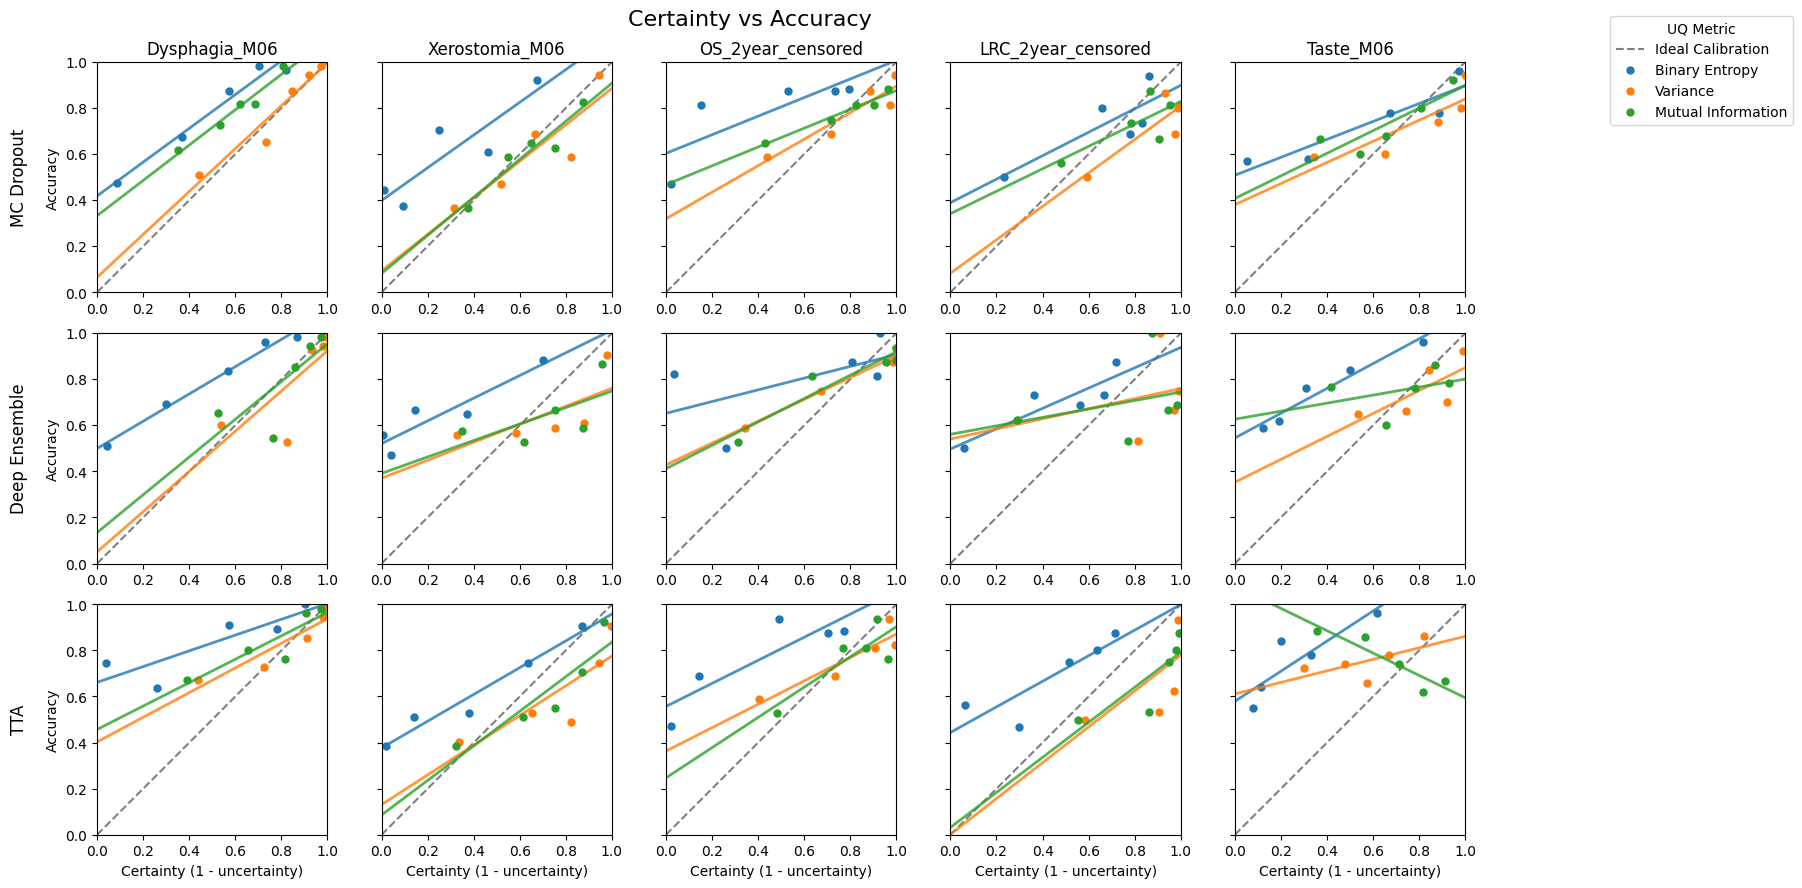

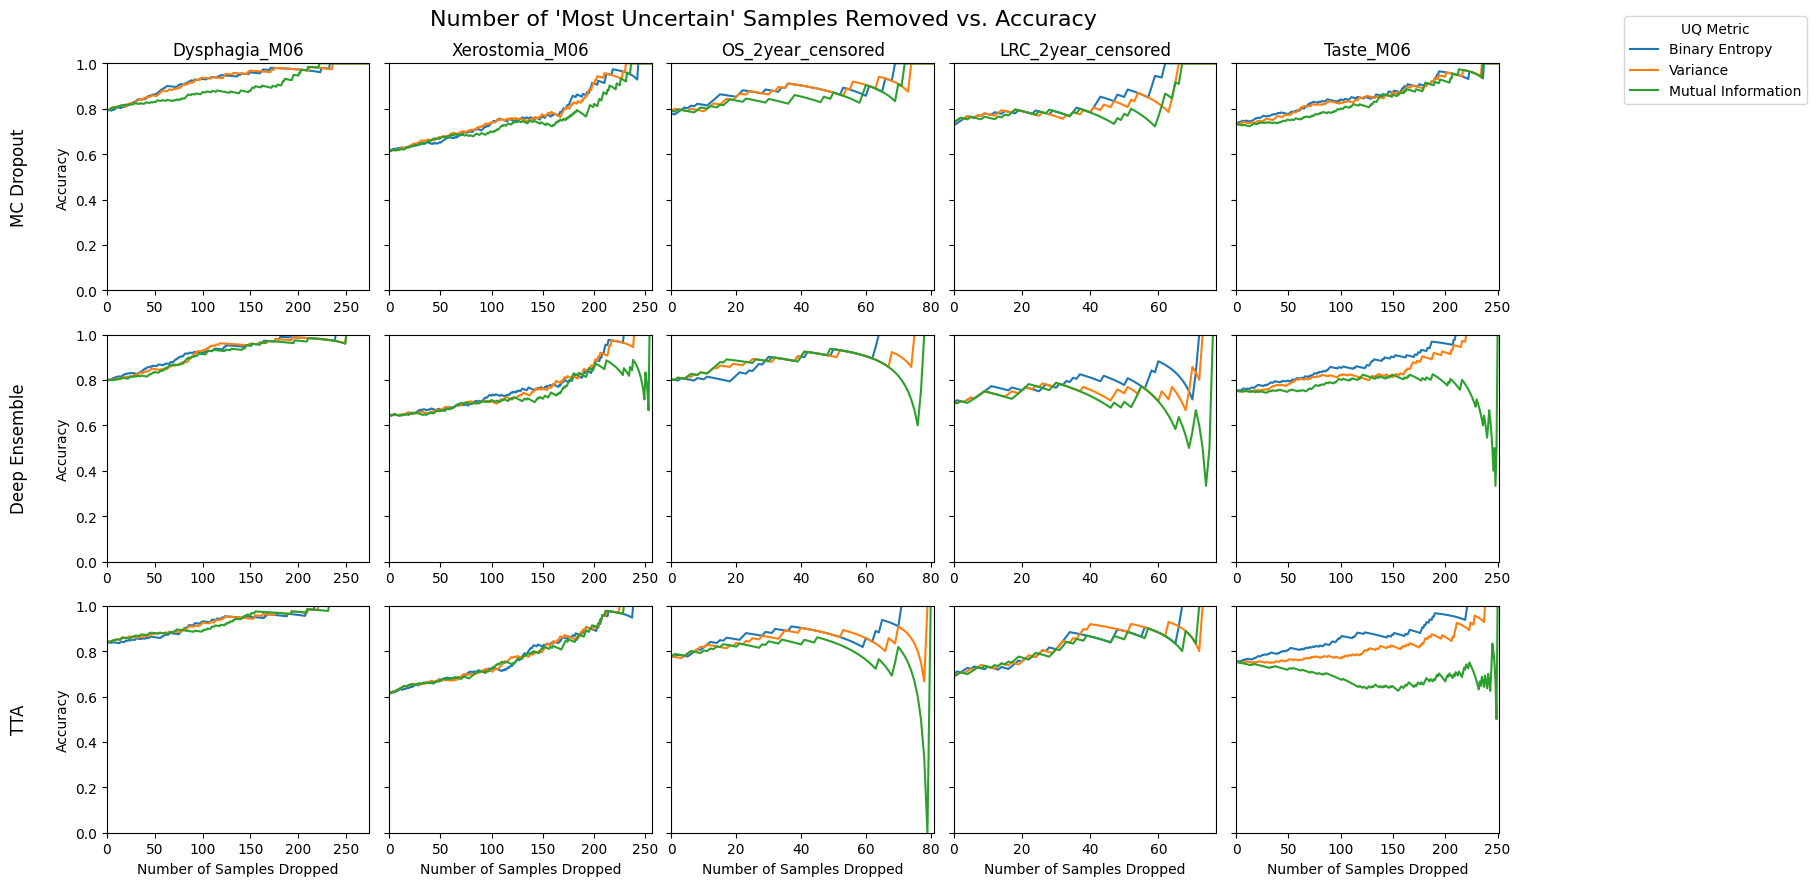

In [14]:
from src.uncertainty.visualisation.plotting_UQ import plot_nested_UQ

# fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="error calibration", row_key="method", col_key="endpoint", N_bins=5)
# plt.show()

fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="calibration", row_key="method", 
                     col_key="endpoint", N_bins=5, normalisation_method="minmax")
plt.show()

fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="sparsification", row_key="method", col_key="endpoint")
plt.show()


In [244]:
UQ_RESULTS_DICT.keys()

dict_keys(['Dysphagia_M06', 'Xerostomia_M06', 'OS_2year_censored', 'LRC_2year_censored'])

In [161]:
UQ_methods_list

['MC Dropout', 'Deep Ensemble', 'TTA']

In [ ]:
from src.uncertainty.metrics.make_table import make_nested_UQ_table
from src.evaluation.metrics.calibration import ECE, ACE

metric_func  = ACE  # NOTE: NOT USED IN MAKE_TABLE.PY

df_metrics = make_nested_UQ_table(
    config,
    UQ_RESULTS_DICT,
    ENDPOINT_TYPES,
    UQ_methods_list,
    UQ_metrics_list,
    metric_func,
    N_bins = 5
)

df_metrics

,endpoint,method,uq_metric,metric_value
0,Dysphagia_M06,MC Dropout,Binary Entropy,0.085882
1,Dysphagia_M06,MC Dropout,Variance,0.002425
2,Dysphagia_M06,MC Dropout,Mutual Information,0.038929
3,Dysphagia_M06,Deep Ensemble,Binary Entropy,0.063097
4,Dysphagia_M06,Deep Ensemble,Variance,0.020847
5,Dysphagia_M06,Deep Ensemble,Mutual Information,0.010934
6,Dysphagia_M06,TTA,Binary Entropy,0.154690
7,Dysphagia_M06,TTA,Variance,0.012007
8,Dysphagia_M06,TTA,Mutual Information,0.021475
9,Xerostomia_M06,MC Dropout,Binary Entropy,0.110901
